## Predicting HDB Resale Flat Prices

The dataset contains historical data from JANUARY 2017 to MARCH 2026.

In [232]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor 
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

In [234]:
data = pd.read_csv("resale flat prices.csv")

In [235]:
data

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0
...,...,...,...,...,...,...,...,...,...,...,...
226466,2026-02,YISHUN,EXECUTIVE,292,YISHUN ST 22,01 TO 03,165.0,Apartment,1992,65 years 05 months,940000.0
226467,2026-02,YISHUN,EXECUTIVE,258,YISHUN ST 22,01 TO 03,148.0,Maisonette,1985,58 years 04 months,800000.0
226468,2026-01,YISHUN,EXECUTIVE,643,YISHUN ST 61,10 TO 12,142.0,Apartment,1987,60 years 09 months,825000.0
226469,2026-01,YISHUN,EXECUTIVE,643,YISHUN ST 61,04 TO 06,146.0,Maisonette,1987,60 years 08 months,788000.0


In [238]:
data.info() # Check for missing data - no missing data found

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226471 entries, 0 to 226470
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   month                226471 non-null  object 
 1   town                 226471 non-null  object 
 2   flat_type            226471 non-null  object 
 3   block                226471 non-null  object 
 4   street_name          226471 non-null  object 
 5   storey_range         226471 non-null  object 
 6   floor_area_sqm       226471 non-null  float64
 7   flat_model           226471 non-null  object 
 8   lease_commence_date  226471 non-null  int64  
 9   remaining_lease      226471 non-null  object 
 10  resale_price         226471 non-null  float64
dtypes: float64(2), int64(1), object(8)
memory usage: 19.0+ MB


In [240]:
# Getting HDB age using a function 

def get_hdb_age(lease):
    lease = str(lease).lower().strip()
    lease = lease.replace("years", "").replace("year","")
    lease = lease.replace("months","").replace("month","")

    parts = lease.split()

    years = 0
    months = 0 

    if len(parts) == 2:
        years = int(parts[0])
        months = int(parts[1])
    elif len(parts) == 1:
        years = int(parts[0])

    if months >=6:                   # Rounding up of the age to a whole number
        lease_left = years + 1

    else:
        lease_left = years 

    return 99 - lease_left

data["hdb_age"] = data["remaining_lease"].apply(get_hdb_age)

data["hdb_age"]

0         38
1         38
2         37
3         37
4         37
          ..
226466    34
226467    41
226468    38
226469    38
226470    38
Name: hdb_age, Length: 226471, dtype: int64

In [242]:
data.info

<bound method DataFrame.info of           month        town  flat_type block        street_name storey_range  \
0       2017-01  ANG MO KIO     2 ROOM   406  ANG MO KIO AVE 10     10 TO 12   
1       2017-01  ANG MO KIO     3 ROOM   108   ANG MO KIO AVE 4     01 TO 03   
2       2017-01  ANG MO KIO     3 ROOM   602   ANG MO KIO AVE 5     01 TO 03   
3       2017-01  ANG MO KIO     3 ROOM   465  ANG MO KIO AVE 10     04 TO 06   
4       2017-01  ANG MO KIO     3 ROOM   601   ANG MO KIO AVE 5     01 TO 03   
...         ...         ...        ...   ...                ...          ...   
226466  2026-02      YISHUN  EXECUTIVE   292       YISHUN ST 22     01 TO 03   
226467  2026-02      YISHUN  EXECUTIVE   258       YISHUN ST 22     01 TO 03   
226468  2026-01      YISHUN  EXECUTIVE   643       YISHUN ST 61     10 TO 12   
226469  2026-01      YISHUN  EXECUTIVE   643       YISHUN ST 61     04 TO 06   
226470  2026-02      YISHUN  EXECUTIVE   611       YISHUN ST 61     04 TO 06   

       

In [244]:
data.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,hdb_age
0,2017-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.0,Improved,1979,61 years 04 months,232000.0,38
1,2017-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.0,New Generation,1978,60 years 07 months,250000.0,38
2,2017-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,262000.0,37
3,2017-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.0,New Generation,1980,62 years 01 month,265000.0,37
4,2017-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.0,New Generation,1980,62 years 05 months,265000.0,37


In [246]:
sorted(data['flat_type'].unique())

['1 ROOM',
 '2 ROOM',
 '3 ROOM',
 '4 ROOM',
 '5 ROOM',
 'EXECUTIVE',
 'MULTI-GENERATION']

In [267]:
sorted(data['flat_model'].unique())

['2-room',
 '3Gen',
 'Adjoined flat',
 'Apartment',
 'DBSS',
 'Improved',
 'Improved-Maisonette',
 'Maisonette',
 'Model A',
 'Model A-Maisonette',
 'Model A2',
 'Multi Generation',
 'New Generation',
 'Premium Apartment',
 'Premium Apartment Loft',
 'Premium Maisonette',
 'Simplified',
 'Standard',
 'Terrace',
 'Type S1',
 'Type S2']

In [269]:
sorted(data['storey_range'].unique())

['01 TO 03',
 '04 TO 06',
 '07 TO 09',
 '10 TO 12',
 '13 TO 15',
 '16 TO 18',
 '19 TO 21',
 '22 TO 24',
 '25 TO 27',
 '28 TO 30',
 '31 TO 33',
 '34 TO 36',
 '37 TO 39',
 '40 TO 42',
 '43 TO 45',
 '46 TO 48',
 '49 TO 51']

In [248]:
sorted(data['town'].unique())

['ANG MO KIO',
 'BEDOK',
 'BISHAN',
 'BUKIT BATOK',
 'BUKIT MERAH',
 'BUKIT PANJANG',
 'BUKIT TIMAH',
 'CENTRAL AREA',
 'CHOA CHU KANG',
 'CLEMENTI',
 'GEYLANG',
 'HOUGANG',
 'JURONG EAST',
 'JURONG WEST',
 'KALLANG/WHAMPOA',
 'MARINE PARADE',
 'PASIR RIS',
 'PUNGGOL',
 'QUEENSTOWN',
 'SEMBAWANG',
 'SENGKANG',
 'SERANGOON',
 'TAMPINES',
 'TOA PAYOH',
 'WOODLANDS',
 'YISHUN']

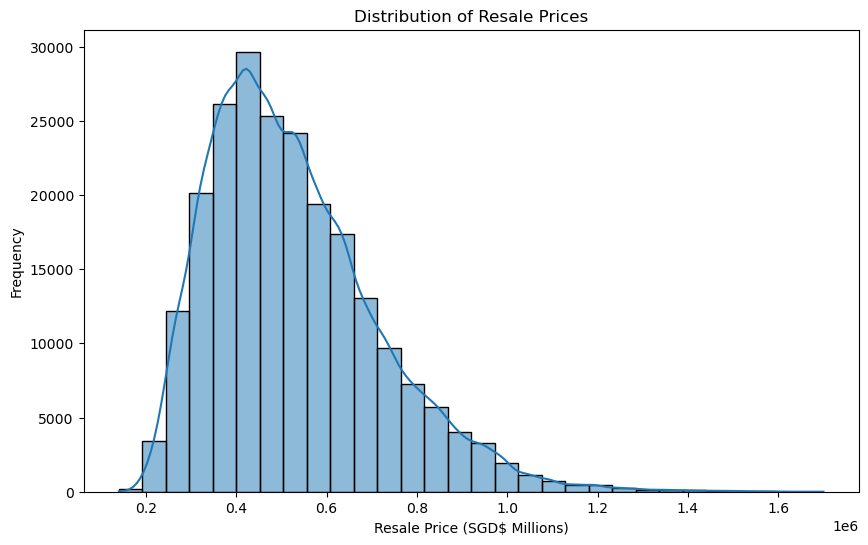

In [250]:
plt.figure(figsize=(10,6))
sns.histplot(data['resale_price'], bins = 30, kde = True)
plt.title('Distribution of Resale Prices')
plt.xlabel('Resale Price (SGD$ Millions)')
plt.ylabel('Frequency')
plt.show()

### Resale Price Distribution for Resale HDB Flats (Jan 2017 to March 2026)

The histogram illustrates the frequency distribution of resale prices for flats from January 2017 to March 2026. Most resale prices cluster between SGD 300,000 and SGD 500,000, where a high concentration of flats are sold in this range of price. Distribution is a right-skewed pattern, indicating that fewer flats are being sold at higher price range, of more than SGD $600,000. The short tail on the lower end implies that there is a minimum threshold of about SGD200,000 where fewer flats are being sold at a price range closer to the threshold. The distribution indicates that there is a high demand or there is a market for mid-priced flats. 

/var/folders/g5/dytxyb0j79z2kyyt76ppcfbm0000gn/T/ipykernel_78982/1494950141.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x = 'flat_type', y = 'resale_price', data=data, palette = 'coolwarm')


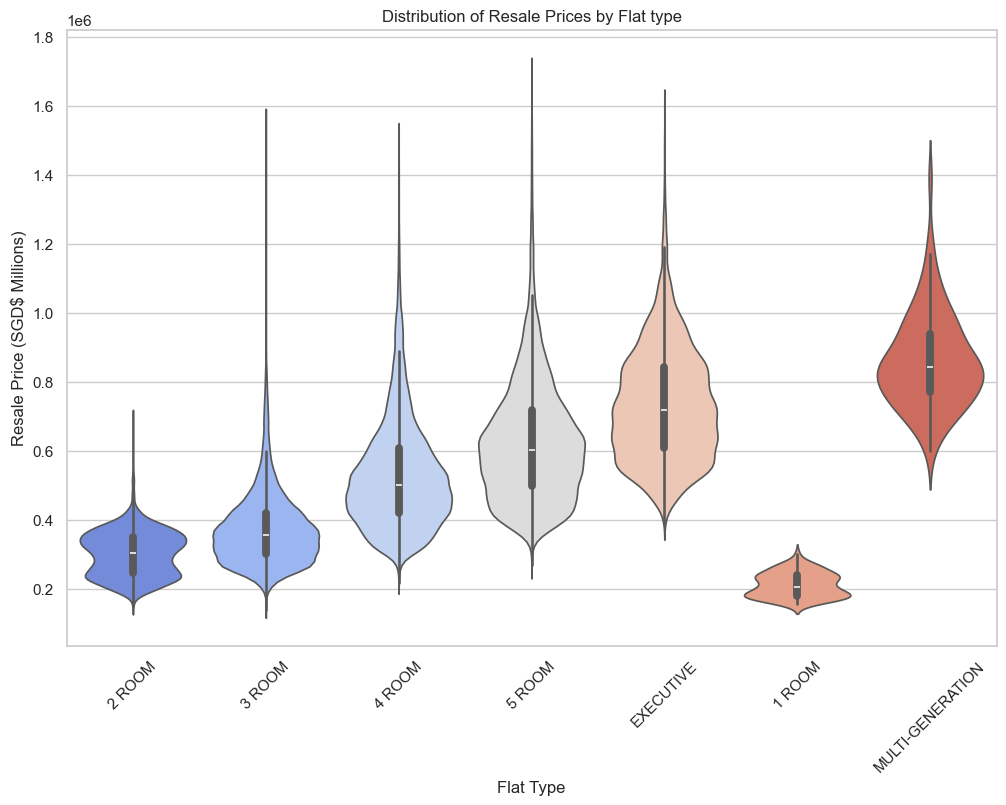

In [277]:
sns.set(style = "whitegrid")

plt.figure(figsize = (12,8)) 
sns.violinplot(x = 'flat_type', y = 'resale_price', data=data, palette = 'coolwarm')
plt.title('Distribution of Resale Prices by Flat type')
plt.ylabel('Resale Price (SGD$ Millions)')
plt.xlabel('Flat Type')
plt.xticks(rotation = 45) 

plt.show()

### Distribution of Resale Price by Flat Type
The violin plot illustrates the distribution of resale prices segmented by flat types. It shows that 5 Room flats have a wider spread of prices while 1 Room flats have the smallest spread of prices. Multi-generation flats have the highest median prices compared to the other flat types. 2 Room and 1 Room flats have 2 distinct bulge in the violin plot.

This distribution therefore implies that 5 Room flats prices are more dispersed, suggesting that there may be factors that create this price variation while 1 Room flats have smaller price distribution which indicates stable and predictable price range. Multi-generation flats tend to be sold at higher resale price with a relatively even distributed around a central value, as seen from the smooth bell-shaped. Additionally, 2 Room and 1 Room flats may have distinct sub-markets within the same flat type which may indicate possible factors that drive such price range.

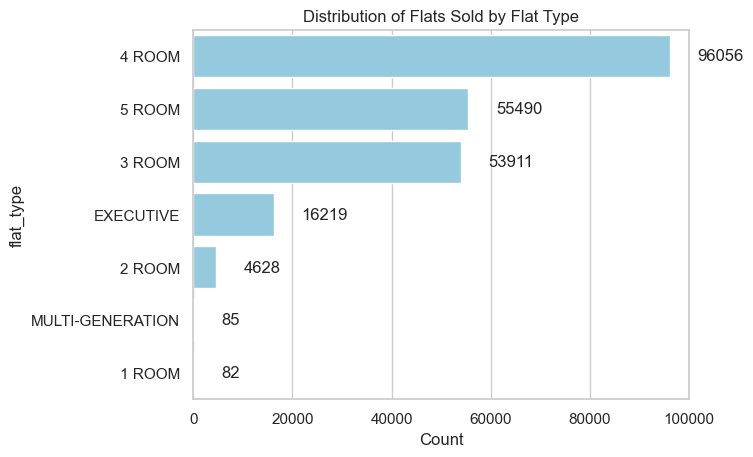

In [368]:
ax = sns.barplot(y = data['flat_type'].value_counts().index, x = data['flat_type'].value_counts().values, color = 'skyblue')
plt.title("Distribution of Flats Sold by Flat Type")
ax.bar_label(ax.containers[0], label_type = 'edge', padding = 20)
ax.set_xlim(0,100000)
plt.xlabel('Count')
plt.show()

### Distribution of Flats Sold by Flat Type

The bar chart illustrates the frequency of flats sold by flat type. 4 Room flats are the most common, followed by 5 Room flats and 3 Room flats. Multi-generation and 1 Room flats are scarce.

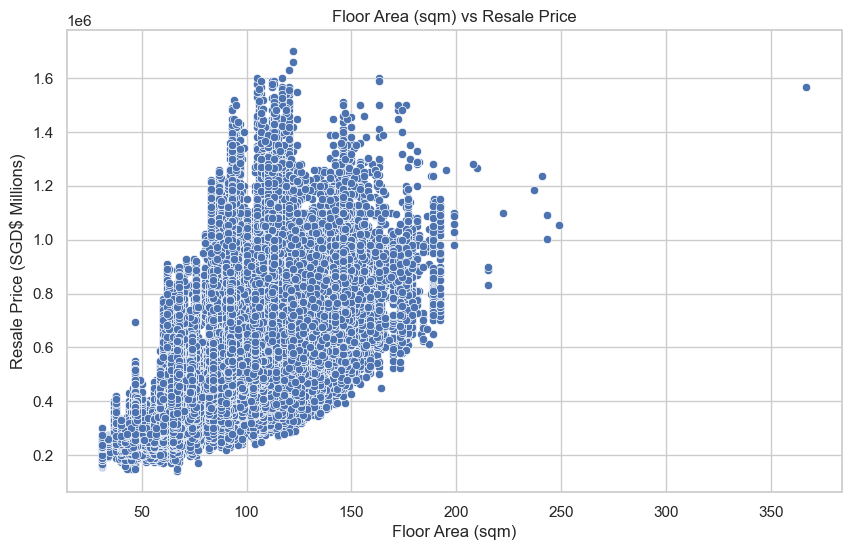

In [264]:
plt.figure(figsize = (10,6))
sns.scatterplot(x = 'floor_area_sqm', y = 'resale_price', data = data)
plt.title('Floor Area (sqm) vs Resale Price')
plt.xlabel('Floor Area (sqm)')
plt.ylabel('Resale Price (SGD$ Millions)')
plt.show()



### Relationship between Floor Area and Resale Price

The scatter plot illustrates the relationship between Floor Area(sqm) and Resale Prices. There is a upward trend of larger flats (sqm) will fetch a higher resale prices. However, the wide spread of resale price for flats with similar size (sqm) indicates that there are other factors that influence resale prices. 

/var/folders/g5/dytxyb0j79z2kyyt76ppcfbm0000gn/T/ipykernel_78982/4136127080.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = data, x = 'storey_range', y = 'resale_price', order = storey_order, palette = 'coolwarm')


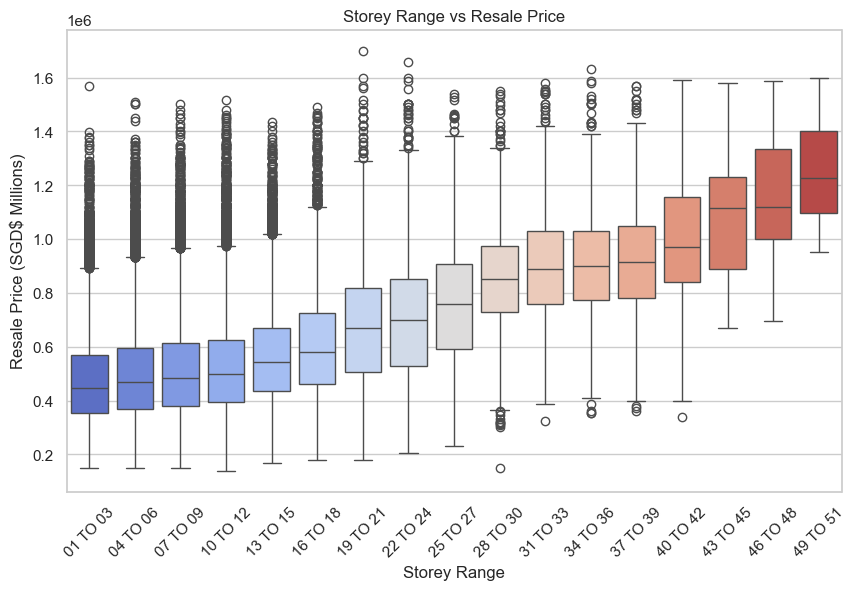

In [279]:
storey_order = sorted(data['storey_range'].dropna().unique())

plt.figure(figsize = (10,6))
sns.boxplot(data = data, x = 'storey_range', y = 'resale_price', order = storey_order, palette = 'coolwarm')
plt.xticks(rotation = 45)
plt.title('Storey Range vs Resale Price')
plt.xlabel('Storey Range')
plt.ylabel('Resale Price (SGD$ Millions)')
plt.show()

### Distribution of Resale Price by Storey Range

The box plot depicts an upward trend in the median resale price across the higher storey ranges, suggesting that flats located on higher floors tend to be sold at higher resale price range. This indicates that storey level may be a contributing factor to housing value where buyers are willing to pay a premium price for units at higher floors. 

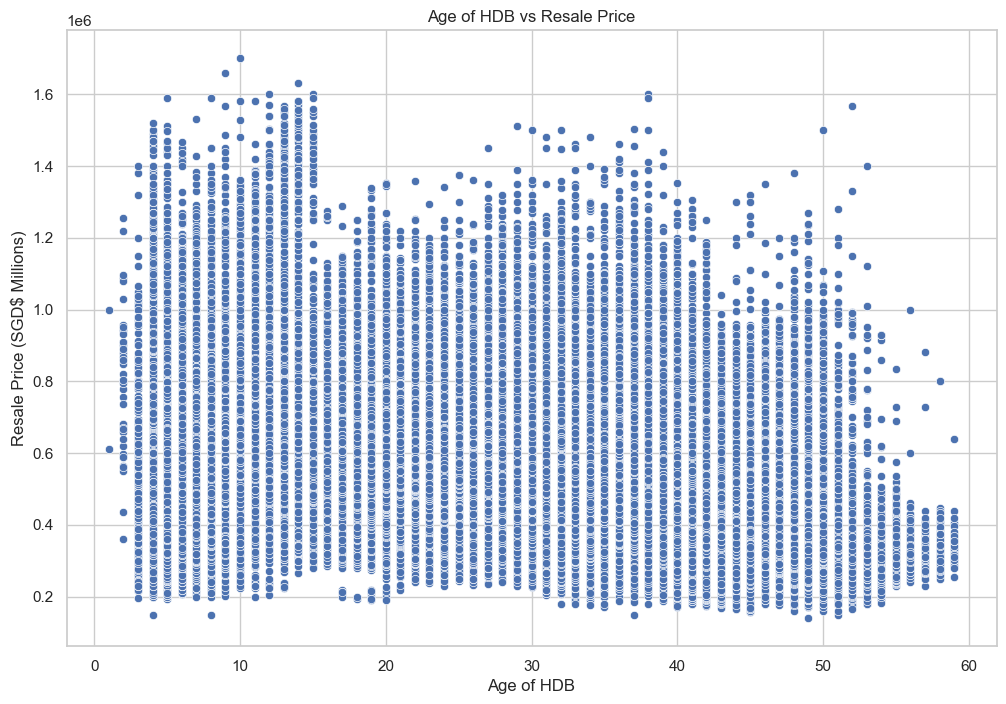

In [286]:
plt.figure(figsize = (12,8))
sns.scatterplot(x = 'hdb_age', y = 'resale_price', data = data)
plt.title('Age of HDB vs Resale Price')
plt.xlabel('Age of HDB')
plt.ylabel('Resale Price (SGD$ Millions)')
plt.show()

### Relationship between Age of HDB and Resale Price

The scatter plot illustrates a gradual downward trend between the Age of HDB and Resale price, indicating older flats tend to have lower resale prices. This corresponds to buyers unwilling to pay much for older flats with shorter remaining lease periods.

/var/folders/g5/dytxyb0j79z2kyyt76ppcfbm0000gn/T/ipykernel_78982/800047624.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = data, y = 'town', x = 'resale_price', order = town_order, palette = 'coolwarm')


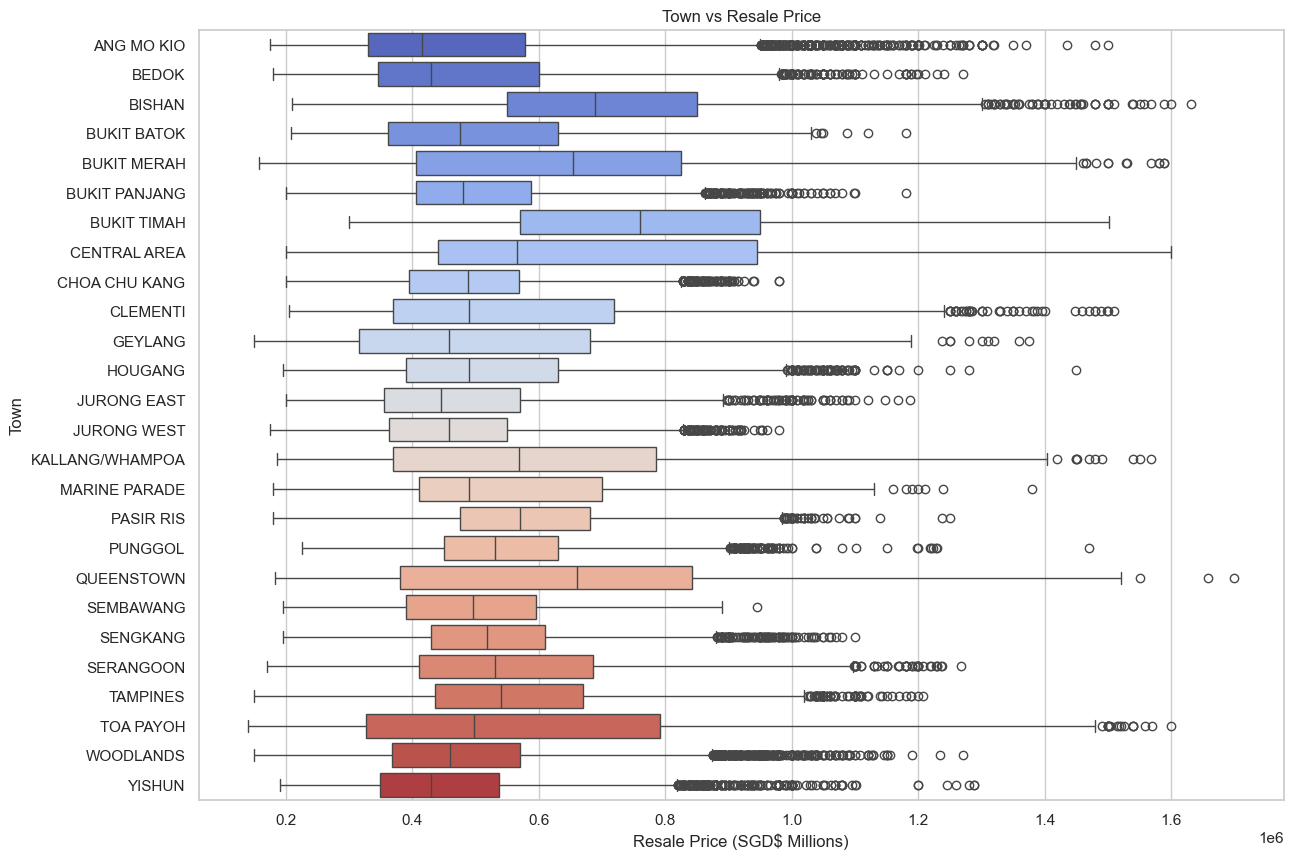

In [306]:
town_order = sorted(data['town'].dropna().unique())

plt.figure(figsize = (14,10))
sns.boxplot(data = data, y = 'town', x = 'resale_price', order = town_order, palette = 'coolwarm')
plt.title('Town vs Resale Price')
plt.xlabel('Resale Price (SGD$ Millions)')
plt.ylabel('Town')
plt.show()

### Distribution of Resale Price by Town

The box plot depicts some towns have a higher median resale price, such as Bukit Timah, Central Area, Bishan, Queenstown and Kallang / Whampoa. On the other hand, towns such as Ang Mo Kio, Yishun and Woodlands have more affordable price range with tighter price distribution, suggesting that there is a high demand for lower price range flats. 

/var/folders/g5/dytxyb0j79z2kyyt76ppcfbm0000gn/T/ipykernel_78982/3687982398.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = data, y = 'flat_model', x = 'resale_price', order = flat_model_order, palette = 'coolwarm')


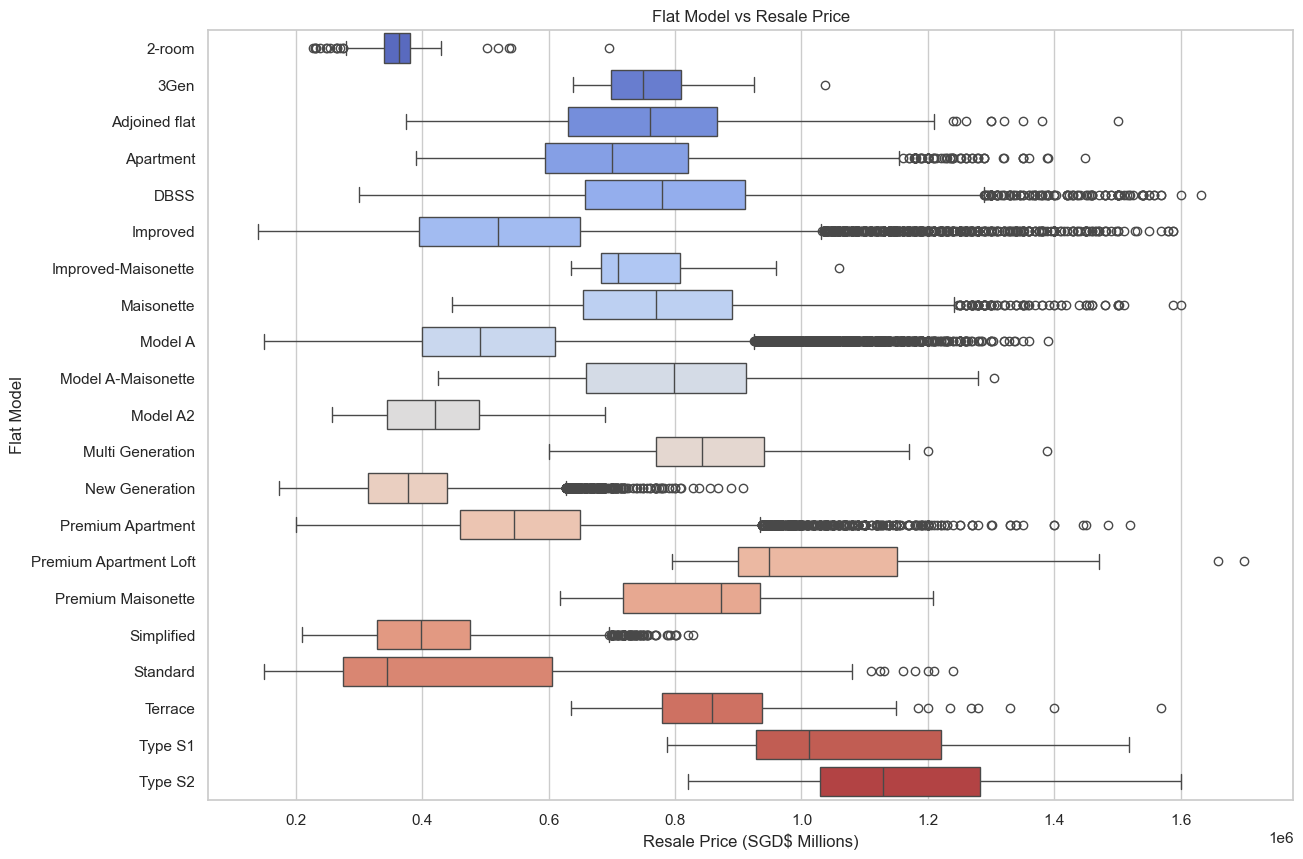

In [304]:
flat_model_order = sorted(data['flat_model'].dropna().unique())

plt.figure(figsize = (14,10))
sns.boxplot(data = data, y = 'flat_model', x = 'resale_price', order = flat_model_order, palette = 'coolwarm')
plt.title('Flat Model vs Resale Price')
plt.xlabel('Resale Price (SGD$ Millions)')
plt.ylabel('Flat Model')
plt.show()

### Distribution of Resale Price by Flat Model

The box plot depicts the different flat model and its median resale price. 

### Pairplot 

### Cluster Analysis (elbow method)

### Machine Learning (LR, Random Forest)